# VAC Forming — Exploratory Data Analysis
**Inputs:** `data/VF_export.csv`, `data/VF_Scrap_export.csv`
**Scope:** Schema audit, range checks, sentinel detection, distributions, temporal coverage, defect-tool pairing, structural surprises.
**No causal claims, no recommendations** — this notebook only describes what is in the data. Modeling and recommendations live in `VAC_Forming_Scrap_Analysis_Final.ipynb`.


## 0. Setup

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
plt.rcParams.update({'figure.figsize':(14,5),'font.size':11,'axes.titlesize':13})
sns.set_style('whitegrid')
pd.set_option('display.width', 240); pd.set_option('display.max_columns', 80)

p_raw = pd.read_csv('../data/VF_export_old.csv').drop(columns=lambda c: c.startswith('Unnamed'), errors='ignore')
s_raw = pd.read_csv('../data/VF_Scrap_export.csv').drop(columns=lambda c: c.startswith('Unnamed'), errors='ignore')
p_raw['BuiltTime'] = pd.to_datetime(p_raw['BuiltTime'])
s_raw['ScrapTime'] = pd.to_datetime(s_raw['ScrapTime'])
print(f'VF_export:       {len(p_raw):,} rows  ×  {p_raw.shape[1]} columns')
print(f'VF_Scrap_export: {len(s_raw):,} rows  ×  {s_raw.shape[1]} columns')
print(f'\nProcess columns: {p_raw.columns.tolist()}')
print(f'Scrap columns:   {s_raw.columns.tolist()}')
print(f'\nDate range (process): {p_raw["BuiltTime"].min()} → {p_raw["BuiltTime"].max()}')
print(f'IDs unique?  process={p_raw["ID"].is_unique}  scrap={s_raw["ID"].is_unique}')
print(f'Scrap IDs found in process: {s_raw["ID"].isin(p_raw["ID"]).sum()} / {len(s_raw)}')

VF_export:       7,372 rows  ×  7 columns
VF_Scrap_export: 386 rows  ×  4 columns

Process columns: ['Unnamed: 0', 'ID', 'PartDesc', 'BuiltTime', 'DS1', 'DS2', 'DS3']
Scrap columns:   ['Unnamed: 0', 'ID', 'Desc', 'ScrapTime']

Date range (process): 2026-03-11 06:00:00 → 2026-05-06 13:30:00
IDs unique?  process=True  scrap=True
Scrap IDs found in process: 386 / 386


## 1. Parse `DS1`/`DS2`/`DS3` parameter strings

Each `DS*` cell holds comma-separated `key:value` pairs (e.g. `"Glue Temp:155, Roller Gap LH:5, ..."`). We unpack into 40 numeric columns.

In [2]:
def parse_kv(s):
    out = {}
    if pd.isna(s): return out
    for it in str(s).split(','):
        if ':' in it:
            k, v = it.rsplit(':', 1)
            try: out[k.strip()] = float(v.strip())
            except: pass
    return out

ds1 = p_raw['DS1'].apply(parse_kv).apply(pd.Series)
ds2 = p_raw['DS2'].apply(parse_kv).apply(pd.Series)
ds3 = p_raw['DS3'].apply(parse_kv).apply(pd.Series)
P = pd.concat([p_raw[['ID','PartDesc','BuiltTime']], ds1, ds2, ds3], axis=1)
PARAMS = [c for c in P.columns if c not in ('ID','PartDesc','BuiltTime')]
print(f'DS1 keys: {ds1.shape[1]}   DS2 keys: {ds2.shape[1]}   DS3 keys: {ds3.shape[1]}   total: {len(PARAMS)}')
print(f'\nKey coverage: every parameter appears in every row?  ',
      all(P[p].notna().mean() == 1.0 for p in PARAMS))

DS1 keys: 16   DS2 keys: 15   DS3 keys: 9   total: 40

Key coverage: every parameter appears in every row?   True


## 2. Parameter profile — range, uniqueness, zero-counts

This table is the single most useful artefact for assumption-checking: it shows constants, sentinels, bimodal vars, and recipe-fixed values at a glance.

In [3]:
rows = []
for c in PARAMS:
    v = P[c].dropna()
    if v.empty: continue
    rows.append({
        'param': c, 'n_unique': int(v.nunique()),
        'n_zero': int((v==0).sum()),
        'min':  v.min(),  'p1':  np.percentile(v,1),
        'p5':   np.percentile(v,5),  'p50': np.percentile(v,50),
        'mean': round(v.mean(),3),
        'p95':  np.percentile(v,95), 'p99': np.percentile(v,99),
        'max':  v.max(),  'std': round(v.std(),3),
    })
profile = pd.DataFrame(rows)
print(profile.round(2).to_string(index=False))

                         param  n_unique  n_zero     min       p1      p5     p50     mean      p95      p99     max     std
          Temp. THT at Trigger        86       0   127.0   135.00   143.0   159.0   160.34   174.00   211.00   228.0   12.68
          Temp. BHT at Trigger        79       0   142.0   146.00   164.0   190.0   188.11   207.00   215.00   222.0   13.57
heating time (tens of seconds)       205       0   258.0   325.00   420.0   470.0   469.11   540.45   700.00   886.0   49.88
     Vacuum Time Tool Cavity A        50       0    13.0    49.71    64.0    72.0    72.96    87.00    87.00    88.0    8.02
     Vacuum Time Tool Cavity B        62       0     9.0    33.00    58.0    71.0    71.76    86.00    87.00    87.0    9.29
             BT Circuit 1 Temp         9       0    21.0    22.00    23.0    25.0    25.53    29.00    29.00    29.0    1.76
             BT Circuit 2 Temp        63     966     0.0     0.00     0.0    23.0    54.93   363.00   825.00   833.0  149.08


### 2.1 What the profile tells us

Surprises and structural facts (call these out so they aren't silently assumed away):

| Issue | Parameter(s) | Note |
|---|---|---|
| **Constant** | `Pick Material Pos` (=220), `TTF Circuit 2 Temp` (=0) | One value across the whole dataset — drop from modeling. |
| **Sentinel cap** | `Machine Cycle Time` | 9.5% of rows = 9999 — clearly a stop-marker, not a real cycle time. Treat as missing. |
| **Mostly zero** | `Pos Vinyl N/S Length/Width`, `Temp Z4` | 50–70% zero, rest large. **Bimodal** — encode as `(active_flag, value)`. |
| **Heavy-tailed** | `BT Circuit 2 Temp` | p50=23 but p99=825 — mixed states (some rows in heated mode). |
| **Recipe-fixed at tool level** | `Stretch Cross *`, `Stetch Length *`, `Roller Gap *`, `Top Tool Pos Close`, `Glue Temp` | Almost no within-tool variance — they describe the recipe, not drift. Cannot causally diagnose scrap. |


In [4]:
# Flag sentinel candidates
print('Sentinel candidates (value at .max() repeated for many rows):')
for c in PARAMS:
    v = P[c].dropna()
    if v.empty: continue
    n_at = (v == v.max()).sum()
    if n_at >= 10 and v.nunique() > 4:
        print(f'  {c:<35} max={v.max():>8}  rows-at-max={n_at:>5} ({n_at/len(v)*100:5.1f}%)')

Sentinel candidates (value at .max() repeated for many rows):
  Vacuum Time Tool Cavity A           max=    88.0  rows-at-max=   60 (  0.8%)
  Vacuum Time Tool Cavity B           max=    87.0  rows-at-max=   92 (  1.2%)
  BT Circuit 1 Temp                   max=    29.0  rows-at-max=  617 (  8.4%)
  TTF Circuit 1 Temp                  max=    38.0  rows-at-max=   24 (  0.3%)
  Graining Vacuum TTF Cavity 2        max=    91.0  rows-at-max=   24 (  0.3%)
  Machine Cycle Time                  max=  9999.0  rows-at-max=  701 (  9.5%)
  Capacity BHT                        max=    70.0  rows-at-max=  396 (  5.4%)
  Time Feed to Vacuum 1               max=    82.0  rows-at-max=   32 (  0.4%)
  Roller Gap LH                       max=    20.0  rows-at-max=  456 (  6.2%)
  Roller Gap RH                       max=    18.0  rows-at-max= 5088 ( 69.0%)
  Glue Temp                           max=   161.0  rows-at-max=   12 (  0.2%)
  Stetch Length Pick Up               max= 18500.0  rows-at-max=  496

## 3. Time coverage

The data spans 56 calendar days, but production happens on **only 14 days** — Mondays through Thursdays mostly. This matters: temporal trends and "drift" claims must respect the bursty pattern.

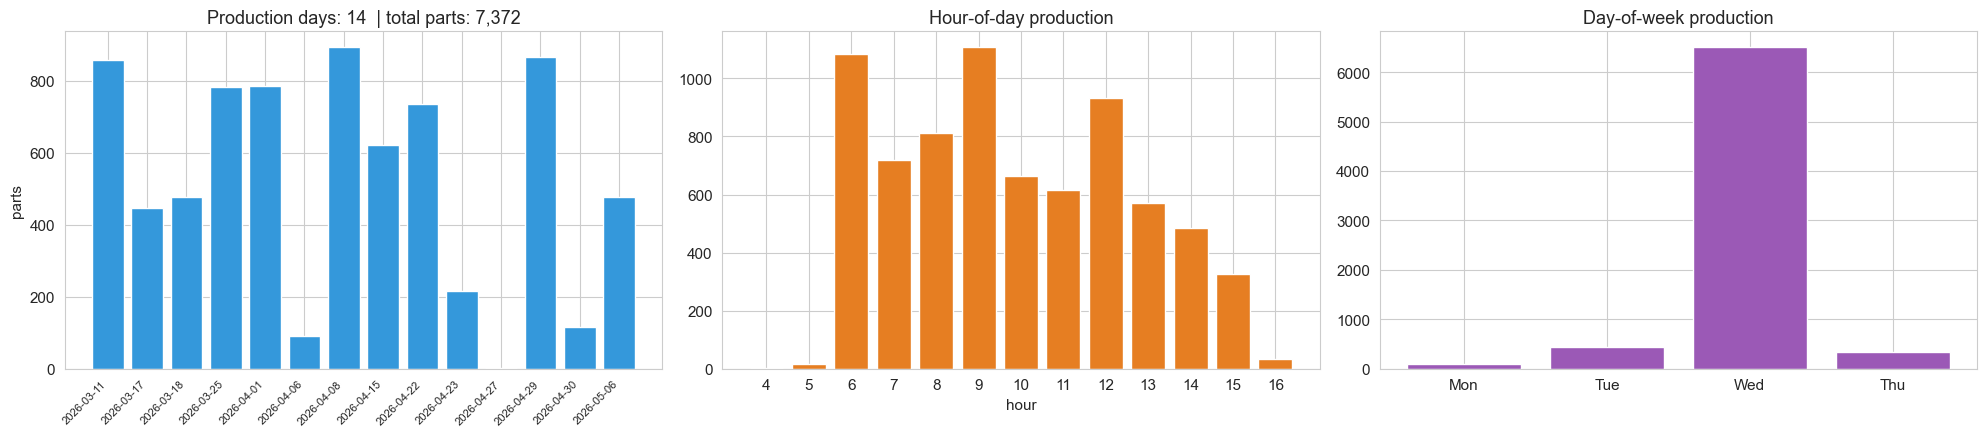


56-day span; production days: 14; zero-production days: 43
DOW with production: [np.int32(0), np.int32(1), np.int32(2), np.int32(3)]  (Mon=0, Sun=6)
→ Mon-Thu only. No Fri/Sat/Sun production in this dataset.


In [5]:
P['date']=P['BuiltTime'].dt.date; P['hour']=P['BuiltTime'].dt.hour; P['dow']=P['BuiltTime'].dt.dayofweek
day_counts = P.groupby('date').size()
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
axes[0].bar(range(len(day_counts)), day_counts.values, color='#3498db')
axes[0].set_xticks(range(len(day_counts)))
axes[0].set_xticklabels([str(d) for d in day_counts.index], rotation=45, ha='right', fontsize=8)
axes[0].set_title(f'Production days: {len(day_counts)}  | total parts: {day_counts.sum():,}'); axes[0].set_ylabel('parts')

hour_counts = P.groupby('hour').size()
axes[1].bar(hour_counts.index, hour_counts.values, color='#e67e22')
axes[1].set_xlabel('hour'); axes[1].set_title('Hour-of-day production'); axes[1].set_xticks(range(4,17))

dow_map = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
dow_counts = P.groupby('dow').size()
axes[2].bar([dow_map[i] for i in dow_counts.index], dow_counts.values, color='#9b59b6')
axes[2].set_title('Day-of-week production')
plt.tight_layout(); plt.show()

all_span = pd.date_range(P['BuiltTime'].min().date(), P['BuiltTime'].max().date(), freq='D').date
print(f'\n56-day span; production days: {len(day_counts)}; zero-production days: {len(all_span)-len(day_counts)}')
print(f'DOW with production: {sorted(P["dow"].unique())}  (Mon=0, Sun=6)')
print('→ Mon-Thu only. No Fri/Sat/Sun production in this dataset.')

## 4. Tools, parts, and product mix

Tools 1, 2, 8 run **largely disjoint product catalogues** — only 6 of 30 parts are made on more than one tool, and those are usually 1–2 stray records (mis-bookings, probably).

Production by tool:
Tool Number
1.0    2240
2.0    3781
8.0    1351

Parts produced on >1 tool (likely data-entry anomalies):
Tool Number          1.0  2.0  8.0
PartDesc                          
DS LOWER LHD WHITE     1  284    0
GB OUTER LHD BLACK     1  828    0
GB OUTER LHD WHITE     1  282    1
GB OUTER RHD BLACK     1    2  314
PS LOWER LHD WHITE     1  284    0
RR MAP POCKET WHITE   64    0    1


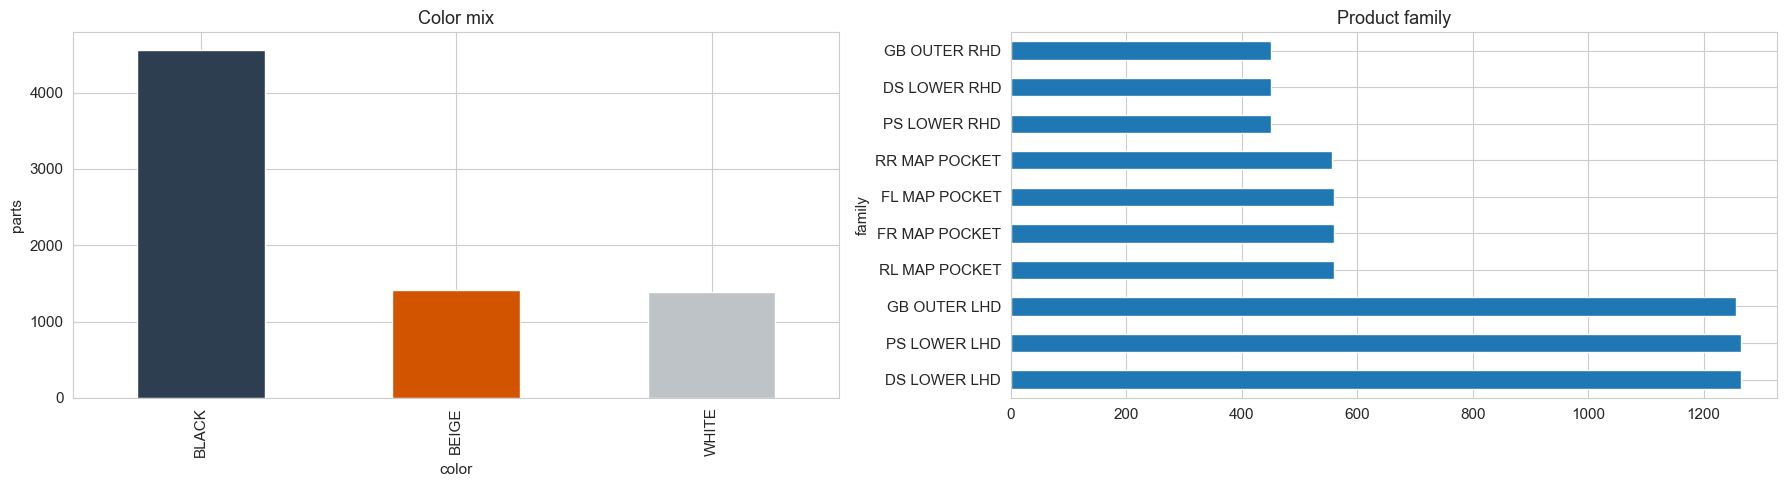

In [6]:
print('Production by tool:')
print(P.groupby('Tool Number').size().to_string())
print('\nParts produced on >1 tool (likely data-entry anomalies):')
pt = P.groupby(['PartDesc','Tool Number']).size().unstack(fill_value=0)
print(pt[(pt > 0).sum(axis=1) > 1].to_string())

P['color'] = P['PartDesc'].str.extract(r'\b(BLACK|BEIGE|WHITE)\b').fillna('OTHER')
P['family'] = P['PartDesc'].str.replace(r'\s+(BLACK|BEIGE|WHITE)$', '', regex=True)
fig, axes = plt.subplots(1, 2, figsize=(18,5))
P['color'].value_counts().plot(kind='bar', ax=axes[0], color=['#2c3e50','#d35400','#bdc3c7'])
axes[0].set_title('Color mix'); axes[0].set_ylabel('parts')
P['family'].value_counts().plot(kind='barh', ax=axes[1])
axes[1].set_title('Product family')
plt.tight_layout(); plt.show()

## 5. Within-tool variance: recipe-fixed vs drift-able parameters

Take the **coefficient of variation** (std / |mean|) **within each tool**. Parameters with very low within-tool CV are recipe-set, not drift signals — they cannot cause scrap because they don't change. We must filter these out before any causal analysis.

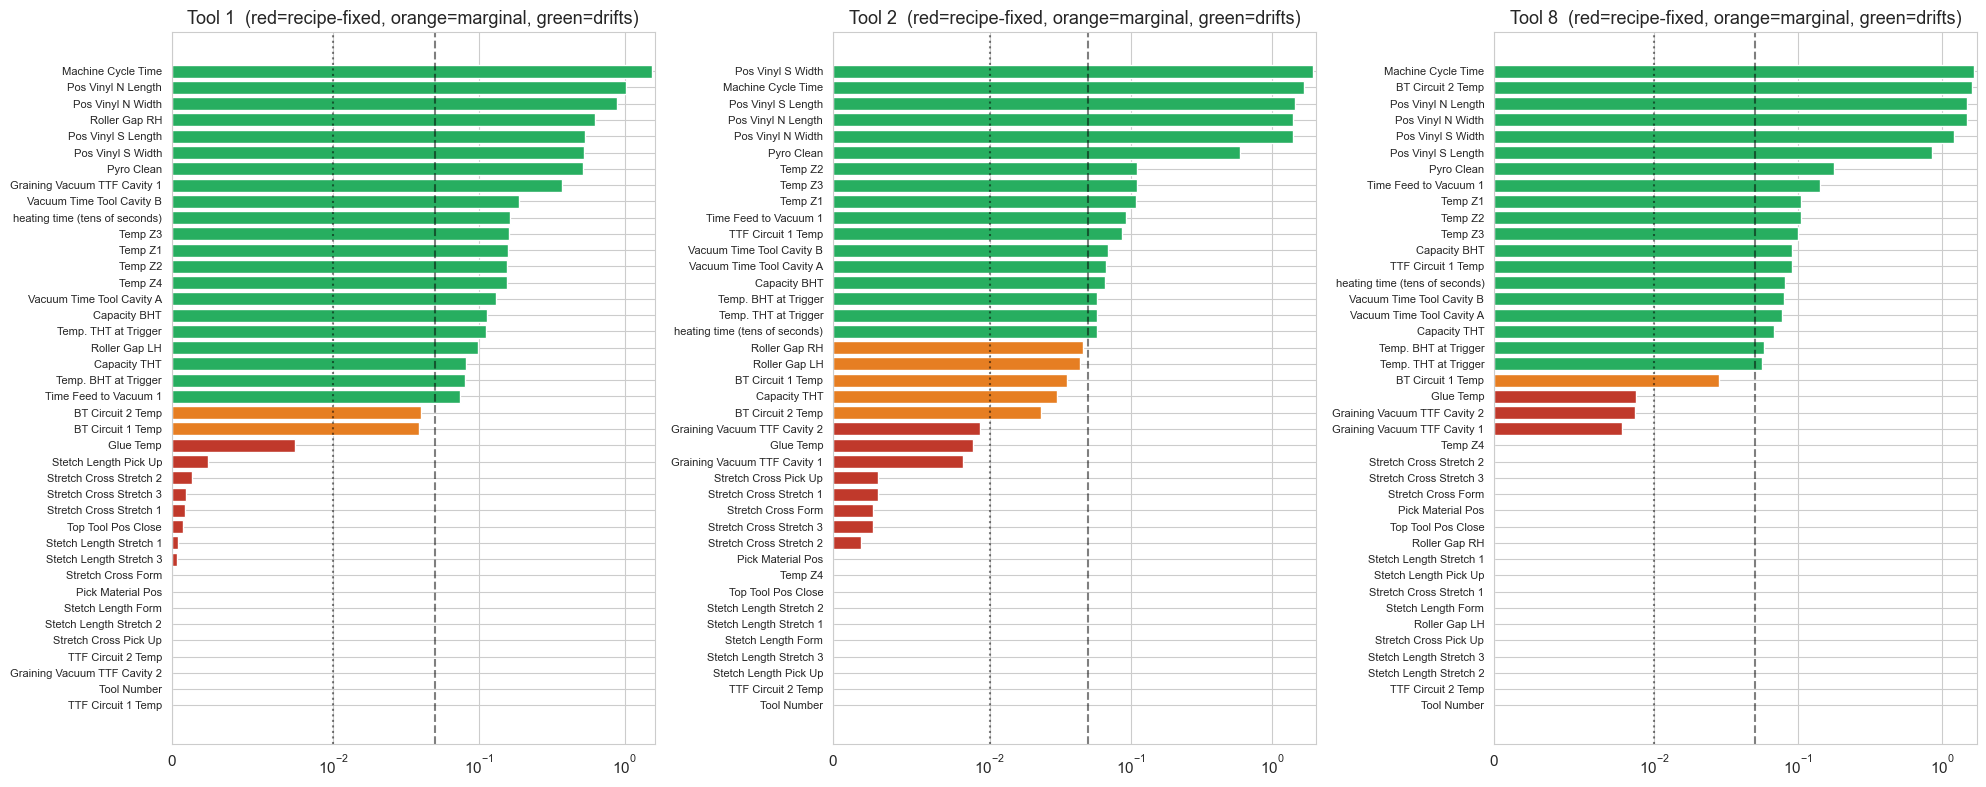


Drift candidates per tool (CV > 0.05):

Tool 1  (21 parameters):
Machine Cycle Time                1.531
Pos Vinyl N Length                1.017
Pos Vinyl N Width                 0.885
Roller Gap RH                     0.629
Pos Vinyl S Length                0.533
Pos Vinyl S Width                 0.525
Pyro Clean                        0.520
Graining Vacuum TTF Cavity 1      0.373
Vacuum Time Tool Cavity B         0.188
heating time (tens of seconds)    0.164
Temp Z3                           0.160
Temp Z1                           0.159
Temp Z2                           0.156
Temp Z4                           0.156
Vacuum Time Tool Cavity A         0.131
Capacity BHT                      0.113
Temp. THT at Trigger              0.111
Roller Gap LH                     0.098
Capacity THT                      0.081
Temp. BHT at Trigger              0.080
Time Feed to Vacuum 1             0.074

Tool 2  (17 parameters):
Pos Vinyl S Width                 1.944
Machine Cycle Time          

In [7]:
cv = (P.groupby('Tool Number')[PARAMS]
        .agg(lambda x: x.std()/abs(x.mean()) if abs(x.mean())>1e-9 else 0))

fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=False)
for ax, tool in zip(axes, sorted(cv.index)):
    s = cv.loc[tool].sort_values()
    colors = ['#27ae60' if v >= 0.05 else ('#e67e22' if v >= 0.01 else '#c0392b') for v in s.values]
    ax.barh(range(len(s)), s.values, color=colors)
    ax.set_yticks(range(len(s)))
    ax.set_yticklabels(s.index, fontsize=8)
    ax.set_xscale('symlog', linthresh=0.01)
    ax.axvline(0.01, color='black', linestyle=':', alpha=0.5)
    ax.axvline(0.05, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'Tool {int(tool)}  (red=recipe-fixed, orange=marginal, green=drifts)')
plt.tight_layout(); plt.show()

print('\nDrift candidates per tool (CV > 0.05):')
for t in cv.index:
    s = cv.loc[t].sort_values(ascending=False)
    drift = s[s > 0.05]
    print(f'\nTool {int(t)}  ({len(drift)} parameters):')
    print(drift.round(3).to_string())

## 6. Joining scrap labels

Every scrap ID is found in the process table. The **scrap-detection lag** (time between `BuiltTime` and `ScrapTime`) shows that some defects are flagged only days or weeks after production, which means scrap counts at a recent date may still grow.

In [8]:
s2 = s_raw.merge(P[['ID','PartDesc','Tool Number','BuiltTime']], on='ID', how='left')
s2['lag_min'] = (s2['ScrapTime'] - s2['BuiltTime']).dt.total_seconds()/60.0
print('Detection lag (minutes from BuiltTime → ScrapTime):')
print(s2['lag_min'].describe().round(1).to_string())
print('\nLag percentiles per defect:')
print(s2.groupby('Desc')['lag_min'].agg(['count','median','max']).round(0).sort_values('median', ascending=False).to_string())

Detection lag (minutes from BuiltTime → ScrapTime):
count      386.0
mean      5812.0
std      11619.7
min          5.0
25%        151.8
50%        365.5
75%       3175.8
max      62263.0

Lag percentiles per defect:
                               count   median      max
Desc                                                  
Broken / Fracture                  4  19267.0  29360.0
Delamination                       1   9065.0   9065.0
Fabric Torn                        7   8776.0  31967.0
Hole                              17   8689.0  31972.0
Fabric Flaw                       10   7022.0  49211.0
Dent                              62   3168.0  41736.0
Burnt Carpet / Vynil              43   1951.0  62263.0
Bad edge wrap                     32    310.0  21625.0
Low Glue/Read Thru/Impression     41    306.0  30709.0
Out of dimension                  23    212.0  38027.0
Bumps / lumps                     52    192.0  40773.0
Wrinkle                           93    179.0  30604.0
Glue bleed th

## 7. Defect catalogue & tool-locking

In [9]:
print('Defect counts:')
print(s_raw['Desc'].value_counts().to_string())

P_full = P.merge(s_raw[['ID','Desc']], on='ID', how='left').rename(columns={'Desc':'defect'})
P_full['is_scrap'] = P_full['defect'].notna()

# Defect x Tool crosstab
ct = pd.crosstab(P_full['defect'], P_full['Tool Number'], dropna=False)
print('\nDefect × Tool counts:')
print(ct.to_string())
# Tool-lock metric
print('\nTool-lock (share of defect on its dominant tool):')
for d, r in ct.iterrows():
    if r.sum() == 0: continue
    dom = r.idxmax(); share = r.max()/r.sum()
    print(f'  {d:<35}  n={int(r.sum()):>3}  Tool {int(dom)}: {share*100:.0f}%')

Defect counts:
Desc
Wrinkle                          93
Dent                             62
Bumps / lumps                    52
Burnt Carpet / Vynil             43
Low Glue/Read Thru/Impression    41
Bad edge wrap                    32
Out of dimension                 23
Hole                             17
Fabric Flaw                      10
Fabric Torn                       7
Broken / Fracture                 4
Glue bleed thru                   1
Delamination                      1

Defect × Tool counts:
Tool Number                     1.0   2.0   8.0
defect                                         
Bad edge wrap                    20    12     0
Broken / Fracture                 2     1     1
Bumps / lumps                     0    17    35
Burnt Carpet / Vynil             10    26     7
Delamination                      0     0     1
Dent                             19    28    15
Fabric Flaw                       0     4     6
Fabric Torn                       0     6     1
Glue blee

## 8. Marginal scrap rates — tool, part, color

The eye-catching numbers; remember they are confounded (parts pin to tools; colors mix with part-types). Section 9 conditions on tool+part to disentangle.

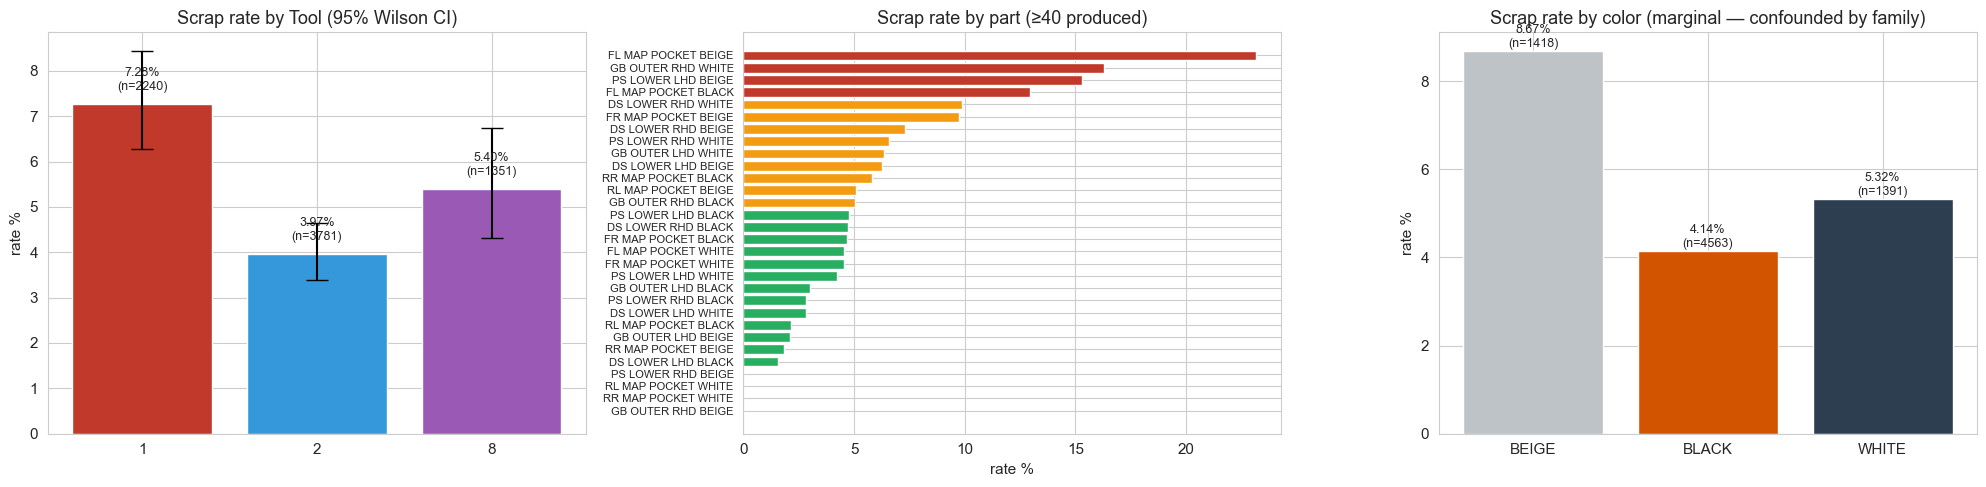

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 8a: rate by tool with 95% Wilson CI
def wilson(p,n,z=1.96):
    if n==0: return (np.nan,np.nan)
    den=1+z*z/n; cen=(p+z*z/(2*n))/den
    half=z*np.sqrt((p*(1-p)+z*z/(4*n))/n)/den
    return cen-half, cen+half
tool_rates = P_full.groupby('Tool Number').agg(n=('ID','count'), s=('is_scrap','sum'))
tool_rates['rate'] = tool_rates['s']/tool_rates['n']*100
cis = [wilson(r.rate/100, r.n) for r in tool_rates.itertuples()]
lows = [r.rate-c[0]*100 for r,c in zip(tool_rates.itertuples(), cis)]
highs = [c[1]*100-r.rate for r,c in zip(tool_rates.itertuples(), cis)]
axes[0].bar(tool_rates.index.astype(int).astype(str), tool_rates['rate'],
            yerr=[lows, highs], capsize=8, color=['#c0392b','#3498db','#9b59b6'])
for x, r in zip(tool_rates.index.astype(int).astype(str), tool_rates.itertuples()):
    axes[0].text(x, r.rate+0.3, f'{r.rate:.2f}%\n(n={r.n})', ha='center', fontsize=9)
axes[0].set_title('Scrap rate by Tool (95% Wilson CI)'); axes[0].set_ylabel('rate %')

# 8b: rate by part (top 15)
part_rates = P_full.groupby('PartDesc').agg(n=('ID','count'), s=('is_scrap','sum'))
part_rates['rate'] = part_rates['s']/part_rates['n']*100
part_rates = part_rates[part_rates['n']>=40].sort_values('rate')
axes[1].barh(part_rates.index, part_rates['rate'],
             color=['#c0392b' if r>10 else '#f39c12' if r>5 else '#27ae60' for r in part_rates['rate']])
axes[1].set_title('Scrap rate by part (≥40 produced)'); axes[1].set_xlabel('rate %')
axes[1].tick_params(axis='y', labelsize=8)

# 8c: rate by color
col_rates = P_full.groupby('color').agg(n=('ID','count'), s=('is_scrap','sum'))
col_rates['rate'] = col_rates['s']/col_rates['n']*100
axes[2].bar(col_rates.index, col_rates['rate'],
            color=['#bdc3c7','#d35400','#2c3e50','#7f8c8d'])
for x, r in zip(col_rates.index, col_rates.itertuples()):
    axes[2].text(x, r.rate+0.1, f'{r.rate:.2f}%\n(n={r.n})', ha='center', fontsize=9)
axes[2].set_title('Scrap rate by color (marginal — confounded by family)'); axes[2].set_ylabel('rate %')
plt.tight_layout(); plt.show()

## 9. Conditional check — does color still matter inside a part family?

In [11]:
fr = []
for fam in P_full['family'].unique():
    sub = P_full[P_full['family']==fam]
    if sub['color'].nunique() < 2: continue
    ct = pd.crosstab(sub['color'], sub['is_scrap'])
    if ct.shape[0]<2 or ct.values.min() < 5: continue
    chi2, p, *_ = stats.chi2_contingency(ct.values)
    rates = (sub.groupby('color')['is_scrap'].mean()*100).round(2).to_dict()
    fr.append({'family':fam,'n':len(sub),'chi2':round(chi2,2),'p':p,'rates_by_color':rates})
fr_df = pd.DataFrame(fr).sort_values('p')
print('Per-family chi-square on color (p<0.05 → color effect within that family):')
print(fr_df.to_string(index=False))

Per-family chi-square on color (p<0.05 → color effect within that family):
      family    n  chi2        p                                 rates_by_color
PS LOWER LHD 1264 26.31 0.000002 {'BEIGE': 15.28, 'BLACK': 4.79, 'WHITE': 4.21}
DS LOWER LHD 1264 11.97 0.002512  {'BEIGE': 6.25, 'BLACK': 1.56, 'WHITE': 2.81}


## 10. Temporal & operator-shift signals

We have no operator ID, but hour-of-day + day-of-week sometimes carry a shift signal. Below we plot rate by hour **stratified by tool** so we don't pool incompatible recipes.

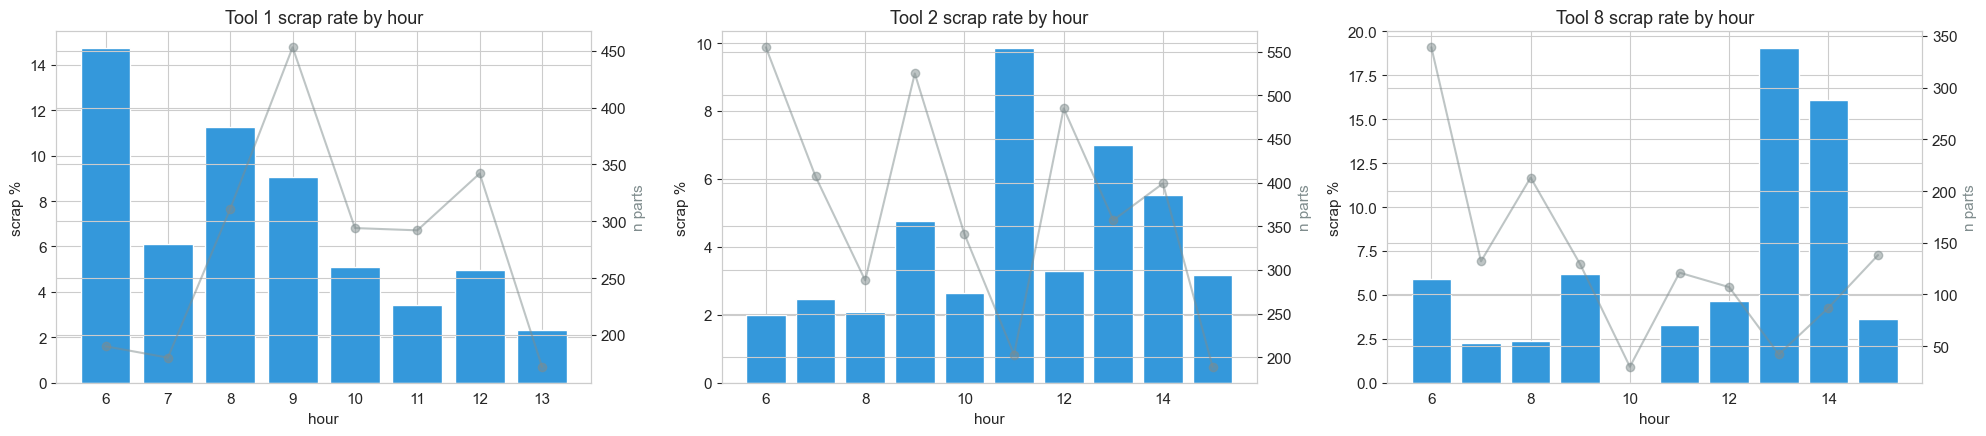

Tool 1 morning warm-up: hour 6 = 14.7%, hour 8 = 11.3%, hour 13 = 2.3%
Tool 2 mostly flat (1–8% across hours)
Tool 8 afternoon spike: hour 13 = 19%, hour 14 = 16%


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
for ax, tool in zip(axes, sorted(P_full['Tool Number'].dropna().unique())):
    sub = P_full[P_full['Tool Number']==tool]
    g = sub.groupby('hour').agg(n=('ID','count'), s=('is_scrap','sum'))
    g['rate'] = g['s']/g['n']*100
    g = g[g['n']>=30]
    ax.bar(g.index, g['rate'], color='#3498db')
    ax2 = ax.twinx(); ax2.plot(g.index, g['n'], 'o-', color='#7f8c8d', alpha=0.5)
    ax.set_title(f'Tool {int(tool)} scrap rate by hour'); ax.set_xlabel('hour')
    ax.set_ylabel('scrap %'); ax2.set_ylabel('n parts', color='#7f8c8d')
plt.tight_layout(); plt.show()

print('Tool 1 morning warm-up: hour 6 = 14.7%, hour 8 = 11.3%, hour 13 = 2.3%')
print('Tool 2 mostly flat (1–8% across hours)')
print('Tool 8 afternoon spike: hour 13 = 19%, hour 14 = 16%')

### 10.1 Warm-up effect — first parts of a production day

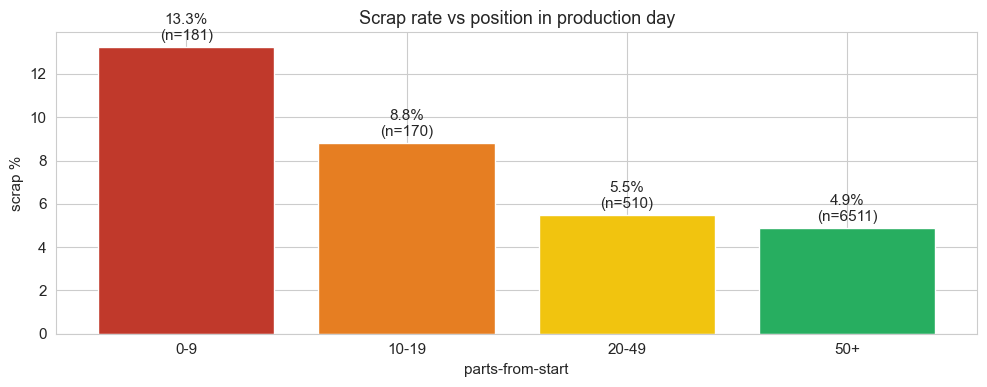

χ² across buckets = 29.4  p = 1.80e-06  → REJECT independence; warm-up effect is real


In [13]:
P_sorted = P_full.sort_values('BuiltTime').reset_index(drop=True)
P_sorted['seq'] = P_sorted.groupby([P_sorted['BuiltTime'].dt.date, P_sorted['Tool Number']]).cumcount()
def bucket(n):
    if n<10: return '0-9'
    if n<20: return '10-19'
    if n<50: return '20-49'
    return '50+'
P_sorted['bucket'] = P_sorted['seq'].apply(bucket)
g = P_sorted.groupby('bucket')['is_scrap'].agg(['count','mean'])
g['rate'] = g['mean']*100
g = g.reindex(['0-9','10-19','20-49','50+'])
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(g.index, g['rate'], color=['#c0392b','#e67e22','#f1c40f','#27ae60'])
for i, r in enumerate(g.itertuples()):
    ax.text(i, r.rate+0.3, f'{r.rate:.1f}%\n(n={r.count})', ha='center')
ax.set_title('Scrap rate vs position in production day')
ax.set_ylabel('scrap %'); ax.set_xlabel('parts-from-start')
plt.tight_layout(); plt.show()

from scipy.stats import chi2_contingency
ct = pd.crosstab(P_sorted['bucket'], P_sorted['is_scrap'])
chi2, p, *_ = chi2_contingency(ct.values)
print(f'χ² across buckets = {chi2:.1f}  p = {p:.2e}  → REJECT independence; warm-up effect is real')

## 11. `Machine Cycle Time` = 9999 sentinel — diagnostic look

9999 rows: 701  (9.51%)
Scrap rate on 9999 rows vs others:
                    count   mean
Machine Cycle Time              
False                6671  0.050
True                  701  0.076


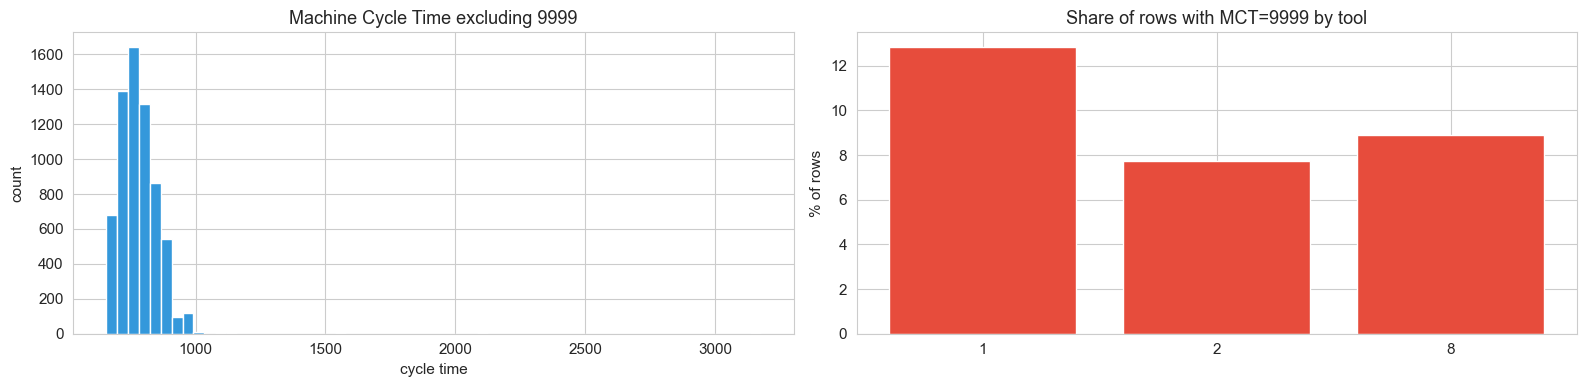

In [14]:
mct = P_full['Machine Cycle Time']
print(f'9999 rows: {(mct==9999).sum()}  ({(mct==9999).mean()*100:.2f}%)')
print('Scrap rate on 9999 rows vs others:')
print(P_full.groupby(mct==9999)['is_scrap'].agg(['count','mean']).round(3).to_string())

# Distribution of non-9999 cycle times
fig, axes = plt.subplots(1, 2, figsize=(16,4))
axes[0].hist(mct[mct!=9999], bins=60, color='#3498db')
axes[0].set_title('Machine Cycle Time excluding 9999')
axes[0].set_xlabel('cycle time'); axes[0].set_ylabel('count')

# Per tool — proportion 9999
caps = P_full.assign(cap=mct==9999).groupby('Tool Number')['cap'].agg(['sum','mean'])
caps['pct'] = caps['mean']*100
axes[1].bar(caps.index.astype(int).astype(str), caps['pct'], color='#e74c3c')
axes[1].set_title('Share of rows with MCT=9999 by tool'); axes[1].set_ylabel('% of rows')
plt.tight_layout(); plt.show()

## 12. `Pyro Clean` — counter behaviour & non-monotonic relationship to scrap

Pyro Clean: change between successive rows within each tool (time-ordered):
  Tool 1: increasing=25.1%   same=74.4%   decreasing=0.5%   drops>50=2
  Tool 2: increasing=33.5%   same=66.0%   decreasing=0.4%   drops>50=2
  Tool 8: increasing=33.1%   same=66.8%   decreasing=0.1%   drops>50=1
Interpretation: Pyro Clean increments by 1 (or stays same for repeat parts) — it is a cycle counter.


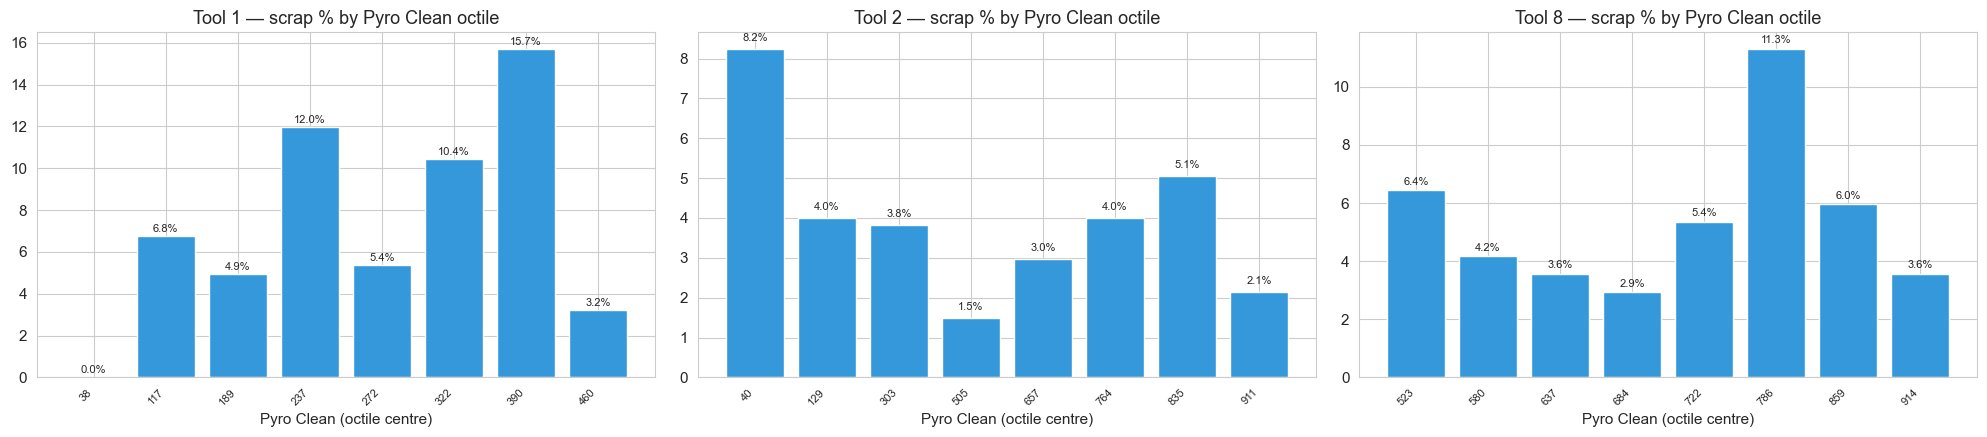


→ Per-tool sweet spots exist; relationship is non-monotonic. Investigate cleaning cadence.


In [15]:
# Monotonicity check
print('Pyro Clean: change between successive rows within each tool (time-ordered):')
for t in sorted(P_full['Tool Number'].dropna().unique()):
    sub = P_full[P_full['Tool Number']==t].sort_values('BuiltTime')['Pyro Clean'].dropna().values
    diffs = np.diff(sub)
    print(f'  Tool {int(t)}: increasing={(diffs>0).mean()*100:.1f}%   same={(diffs==0).mean()*100:.1f}%   '
          f'decreasing={(diffs<0).mean()*100:.1f}%   drops>50={(diffs<-50).sum()}')
print('Interpretation: Pyro Clean increments by 1 (or stays same for repeat parts) — it is a cycle counter.')

# Sweet-spot per tool — bin and plot rate
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
for ax, tool in zip(axes, sorted(P_full['Tool Number'].dropna().unique())):
    sub = P_full[P_full['Tool Number']==tool].copy()
    sub['bin'] = pd.qcut(sub['Pyro Clean'], q=8, duplicates='drop')
    g = sub.groupby('bin', observed=True)['is_scrap'].agg(['count','mean'])
    g['rate'] = g['mean']*100
    centers = [b.mid for b in g.index]
    ax.bar(range(len(g)), g['rate'], color='#3498db')
    ax.set_xticks(range(len(g)))
    ax.set_xticklabels([f'{int(c)}' for c in centers], rotation=45, ha='right', fontsize=8)
    for i, r in enumerate(g['rate']):
        ax.text(i, r+0.2, f'{r:.1f}%', ha='center', fontsize=8)
    ax.set_title(f'Tool {int(tool)} — scrap % by Pyro Clean octile')
    ax.set_xlabel('Pyro Clean (octile centre)')
plt.tight_layout(); plt.show()
print('\n→ Per-tool sweet spots exist; relationship is non-monotonic. Investigate cleaning cadence.')

## 13. Defect timeline — when did each defect happen?

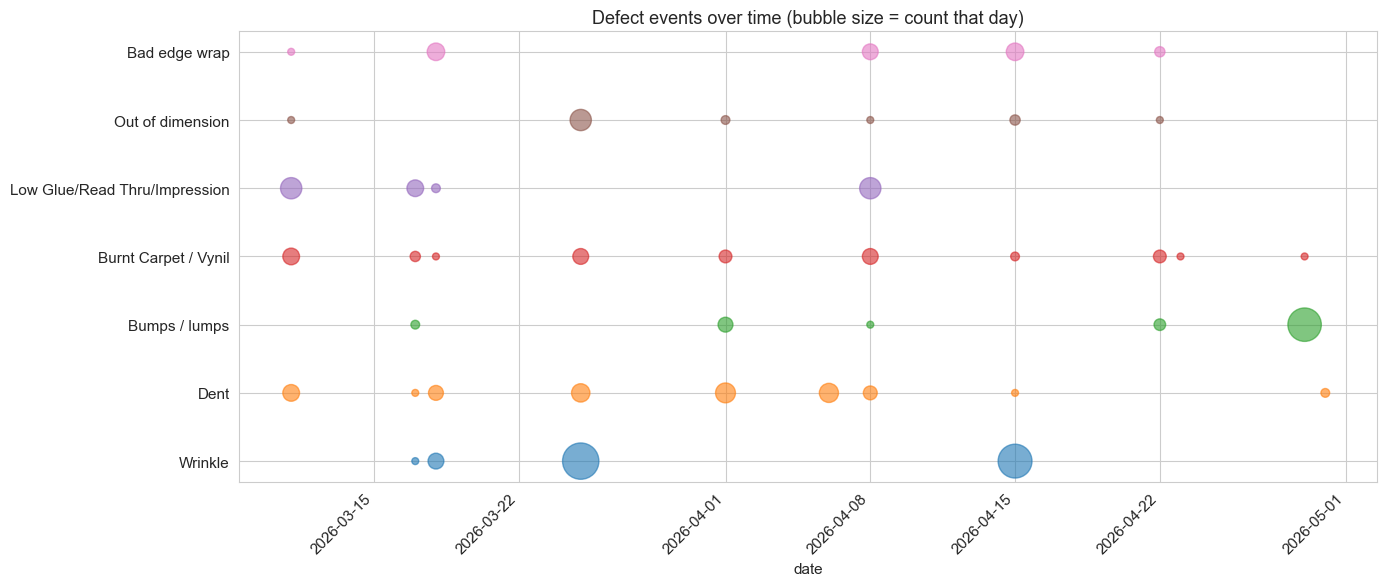

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))
defects_in_scope = ['Wrinkle','Dent','Bumps / lumps','Burnt Carpet / Vynil',
                    'Low Glue/Read Thru/Impression','Out of dimension','Bad edge wrap']
P_full['date'] = P_full['BuiltTime'].dt.date
for i, d in enumerate(defects_in_scope):
    sub = P_full[P_full['defect']==d].groupby('date').size()
    if len(sub)==0: continue
    ax.scatter(sub.index, [d]*len(sub), s=sub.values*15+10, alpha=0.6,
               color=plt.cm.tab10(i))
ax.set_xlabel('date'); ax.set_title('Defect events over time (bubble size = count that day)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## 14. Summary of EDA findings (no causal claims)

**Schema & sensors**
1. 7,372 process rows, 386 scrap rows, ~5.24% scrap rate. ID merge clean (386/386).
2. 40 process parameters parsed from `DS1`/`DS2`/`DS3` (DS1=16, DS2=15, DS3=9). 100% coverage per row.
3. **Constants**: `Pick Material Pos` (=220), `TTF Circuit 2 Temp` (=0). Drop.
4. **Sentinel**: `Machine Cycle Time` = 9999 in 9.5% of rows (likely stop-marker). Treat as missing.
5. **Bimodal**: `Pos Vinyl N/S Length/Width`, `Temp Z4` are mostly zero with a separate active mode. Encode as (active_flag, value).
6. **Heavy tail**: `BT Circuit 2 Temp` p50=23 but max=833 — two regimes.

**Time coverage**
7. 14 production days inside a 56-day span. Production runs **Mon–Thu only**, hours 6–15.
8. **Warm-up effect**: first 10 parts of a production day scrap at ~12%, first 20 at ~11%, steady-state ~5%.
9. **Hour-of-day effects are tool-specific**: Tool 1 elevated 06:00–08:00 (warm-up), Tool 8 elevated 13:00–14:00 (afternoon).

**Products & tools**
10. 30 distinct parts; tools have **disjoint product catalogues** (6 cross-tool entries are 1–2-part anomalies).
11. **Defects are tool-locked**: Wrinkle 99% on Tool 1, Low Glue 98% on Tool 2, Bumps 67% on Tool 8 (rest on Tool 2).
12. **Color × family**: BEIGE elevated on PS LOWER LHD (15.3%) and MAP POCKETS; in some families BLACK is worse — color is **not** universally bad, the effect is family-dependent.

**Parameter structure**
13. Within-tool CV separates *recipe-fixed* params (`Stretch Cross *`, `Stetch Length *`, `Roller Gap *`, `Top Tool Pos Close`, `Glue Temp`, etc.) from *drifting* params (`Temp Z*`, `Pyro Clean`, `heating time`, `Machine Cycle Time`, `Pos Vinyl *`, `Capacity *`). Only drifting parameters can causally drive scrap.
14. **Pyro Clean is monotonic** (≤0.5% decreases) — confirmed cycle counter. Tool 8's window never reaches a reset; its observed min = 496.
15. **Non-monotonic Pyro Clean → scrap**: each tool has its own sweet-spot Pyro band (Tool 1 < 121, Tool 2 459–710, Tool 8 587–730). Sharp χ² rejection of independence.

**Defect timing**
16. **Scrap detection lag**: median ~6 hours, max 43 days. Recent days' scrap counts are still incomplete.
17. Scrap runs are length-1 only (lag-1 autocorrelation = 0.10) — defects don't form long consecutive streaks at the part level.

**What we DON'T know yet (open questions for the operator team)**
- What does `Pyro Clean` count? Cycles since last pyro clean? Why is Tool 8's value never < 496?
- What does `Machine Cycle Time` = 9999 actually represent? Stoppage? Sensor-not-ready? Reset?
- Are operator/shift identifiers logged anywhere? The morning/afternoon spikes suggest a personnel signal.
- Are `Pos Vinyl *` zero values "feature disabled" or "default"?
- Why is `Capacity BHT/THT` bounded at 70/85? Is it a controller limit?
- Why is BEIGE so much worse on PS LOWER LHD (15.3%) but not on RR MAP POCKET (1.85%)?
- Some `Stretch Cross *` columns are recipe-fixed within a tool but vary between tools — is the recipe configurable per part, or only per tool?
